# 라이브러리 로드

In [6]:
import pandas as pd
import numpy as np
from tqdm import tqdm
import os

import librosa

import tensorflow as tf

import matplotlib.pyplot as plt

# 데이터 불러오기

In [2]:
df = pd.read_csv("./data/file_names.csv")
df.head()

,file_name,class,class_num
0,100648-1-0-0.wav,자동차 경적,8
1,100648-1-1-0.wav,자동차 경적,8
2,100648-1-2-0.wav,자동차 경적,8
3,100648-1-3-0.wav,자동차 경적,8
4,100648-1-4-0.wav,자동차 경적,8


In [3]:
df.sample(20)

,file_name,class,class_num
1088,41918-3-0-1.wav,개 짖는 소리,1
1030,33641-3-7-0.wav,개 짖는 소리,1
1992,S-211013_S_104_D_001_0001.mp3,자동차 경적,8
721,173993-3-0-52.wav,개 짖는 소리,1
388,7389-1-4-12.wav,자동차 경적,8
1007,30226-3-1-3.wav,개 짖는 소리,1
1657,S-211024_S_101_C_290_0001.mp3,응급 경보,7
1809,S-211107_S_103_C_020_0001.mp3,화재 경보,10
1803,S-211107_S_103_C_014_0001.mp3,화재 경보,10
130,180156-1-9-0.wav,자동차 경적,8


In [4]:
# 데이터 분포 확인
df['class'].value_counts()

class
개 짖는 소리       1000
자동차 경적         563
화재 경보          186
도난 경보          130
응급 경보           67
침입 경보           21
경찰차 사이렌         18
소방차 사이렌         13
구급차 사이렌         11
공습 경보           10
가스누설 화재 경보       7
Name: count, dtype: int64

### `max_len` 설정하기    
$frames = [\frac{원본 샘플 수 - n\_fft}{hop\_length}]+1$

In [7]:
sr = 16000
n_fft = 1024
hop_length = 256

frame_lengths = []
too_short = []

for root, dirs, files in os.walk("./data/Train"):
    for fname in files:
        path = os.path.join(root, fname)
        
        # Load audio
        y, _ = librosa.load(path, sr=sr)
        
        num_samples = len(y)

        # 너무 짧으면 스킵
        if num_samples <= n_fft:
            too_short.append((fname, num_samples))
            continue
        
        # 프레임 수 계산
        frames = 1 + (num_samples - n_fft) // hop_length
        frame_lengths.append(frames)

# numpy array 변환
frame_lengths = np.array(frame_lengths)

print("총 파일 수:", len(frame_lengths))
print("최소:", frame_lengths.min())
print("최대:", frame_lengths.max())
print("평균:", frame_lengths.mean())
print("중앙값:", np.median(frame_lengths))

print("50th percentile:", np.percentile(frame_lengths, 50))
print("75th percentile:", np.percentile(frame_lengths, 75))
print("90th percentile:", np.percentile(frame_lengths, 90))
print("95th percentile:", np.percentile(frame_lengths, 95))
print("99th percentile:", np.percentile(frame_lengths, 99))

총 파일 수: 2022
최소: 1
최대: 3728
평균: 454.5657764589515
중앙값: 247.0
50th percentile: 247.0
75th percentile: 672.75
90th percentile: 1117.7000000000012
95th percentile: 1748.0
99th percentile: 1921.0


In [8]:
too_short

[('17307-1-0-0.wav', 960),
 ('87275-1-1-0.wav', 800),
 ('87275-1-2-0.wav', 800),
 ('87275-1-3-0.wav', 960)]

In [9]:
df[df['file_name'].isin([f for f, _ in too_short])]

,file_name,class,class_num
80,17307-1-0-0.wav,자동차 경적,8
406,87275-1-1-0.wav,자동차 경적,8
407,87275-1-2-0.wav,자동차 경적,8
408,87275-1-3-0.wav,자동차 경적,8


In [10]:
# 길이가 너무 짧은 음성은 학습에 이용 X
df = df[~df['file_name'].isin([f for f, _ in too_short])]
print(df.shape)
df['class'].value_counts() 

(2022, 3)


class
개 짖는 소리       1000
자동차 경적         559
화재 경보          186
도난 경보          130
응급 경보           67
침입 경보           21
경찰차 사이렌         18
소방차 사이렌         13
구급차 사이렌         11
공습 경보           10
가스누설 화재 경보       7
Name: count, dtype: int64

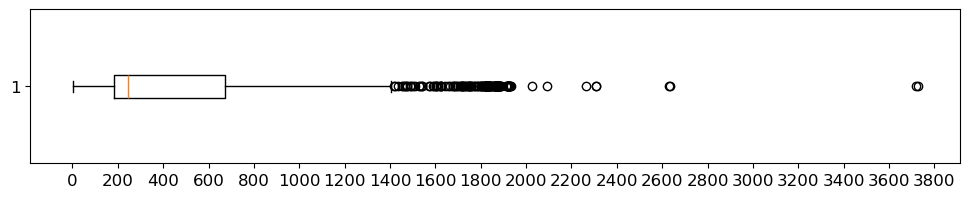

In [23]:
plt.figure(figsize = (12, 2))
plt.boxplot(frame_lengths, vert=False)
plt.xticks(np.arange(0, 4000, 200))
plt.show()


#### `max_len = 1024`
- 길이 분포를 봤더니 90%가 1117프레임 이하 → 이 정도만 커버해도 충분하다고 판단
- 1118 근처이면서 계산/모델에 편한 2의 제곱수인 1024프레임으로 스냅

In [24]:
max_len = 1024

## Dataset Split
Stratified Split => Train, Test를 8:2로 나누기

In [5]:
from sklearn.model_selection import train_test_split

x, X_test, y, y_test = train_test_split(df['file_name'], df['class_num'], test_size=0.2, random_state=42, stratify=df['class_num'])
x.shape, X_test.shape, y.shape, y_test.shape

((1620,), (406,), (1620,), (406,))

In [6]:
y.value_counts()

class_num
1     800
8     450
10    149
5     104
7      53
9      17
2      14
6      10
4       9
3       8
0       6
Name: count, dtype: int64

In [7]:
y_test.value_counts()

class_num
1     200
8     113
10     37
5      26
7      14
2       4
9       4
6       3
3       2
4       2
0       1
Name: count, dtype: int64

# 특징 추출 함수 정의

In [ ]:
def logmel_extraction(df, base_dir='./data/Train', n_fft=1024, hop_length=256, n_mels=64, max_len=400):
    X = []
    y = []

    for fname, label in tqdm(zip(df['file_name'], df['class_num']), total=len(df), desc='Extracting Log-Mel'):
        # 실제 파일 경로 만들기
        path = os.path.join(base_dir, fname)

        # Load audio
        data_x, sampling_rate = librosa.load(path, sr=sr)

        # Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=data_x,
            sr=sampling_rate,  # sampling rate
            n_fft=n_fft,       # fft window size
            hop_length=hop_length,  # fram간 이동 간격
            n_mels=n_mels,     # mel 필터 수
            fmin=50,           # 분석할 최소 주파수
            fmax=sampling_rate // 2  # 분석할 최대 주파수
        )

        # Log scaling (dB)
        logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
        
        # 길이 맞추기
        if logmel.shape[1] < max_len:
            pad_width = max_len - logmel.shape[1]
            logmel = np.pad(logmel, ((0, 0), (0, pad_width)), 'constant')
        else:
            logmel = logmel[:, :max_len]

        X.append(logmel[np.newaxis, :, :])    # (n_mels, time)
        y.append(label)

    return np.array(X), np.array(y)

In [ ]:
def mfcc_extraction(df, base_dir='./data/Train', n_mfcc=50, sr=16000, max_len=400):
    X = []
    y = []

    for fname, label in tqdm(zip(df['file_name'], df['class_num']), total=len(df), desc='Extracting MFCC'):
        # 실제 파일 경로 만들기
        path = os.path.join(base_dir, fname)

        # Load audio
        data_x, sampling_rate = librosa.load(path, sr=sr)

        # MFCC 추출
        mfcc = librosa.feature.mfcc(
            y=data_x,
            sr=sampling_rate,
            n_mfcc=n_mfcc,      # 추출할 MFCC 수
            n_fft=1024,         # STFT 윈도우 크기
            hop_length=256,
            norm='ortho', 
            fmin=50,           # 분석할 최소 주파수
            fmax=sampling_rate // 2  # 분석할 최대 주파수
        ).astype(np.float32)
        
        if mfcc.shape[1] < max_len:
            pad_width = max_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, ((0, 0), (0, pad_width)), 'constant')
        else:
            mfcc = mfcc[:, :max_len]

        X.append(mfcc[np.newaxis, :, :])
        y.append(label)

    return np.array(X), np.array(y)

### 테스트 데이터 특징 추출

In [10]:
test_df = pd.DataFrame({'file_name':X_test, 'class_num':y_test})

In [ ]:
#### 연습
# base_dir='./data/Train'
# mp3=True, sr=16000, n_fft=1024, hop_length=256, n_mels=64
a = []
b = []
original_shapes = []

for fname, label in tqdm(zip(test_df['file_name'], test_df['class_num']), total=len(test_df), desc='Extracting Log-Mel'):
    # 실제 파일 경로 만들기
    path = os.path.join('./data/Train', fname)

    # Load audio
    data_x, sampling_rate = librosa.load(path, sr=16000)

    # mp3 파일은 앞 9초 제거
    if fname.endswith('.mp3'):
        data_x = data_x[9 * 16000:]

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=data_x,
        sr=16000,  # sampling rate
        n_fft=1024,       # fft window size
        hop_length=256,  # fram간 이동 간격
        n_mels=64,     # mel 필터 수
        fmin=50,           # 분석할 최소 주파수
        fmax=16000 // 2  # 분석할 최대 주파수
    )

    # Log scaling (dB)
    logmel = librosa.power_to_db(mel, ref=np.max).astype(np.float32)
            
    # 길이 맞추기
#     if logmel.shape[1] < max_len:
#         pad_width = max_len - logmel.shape[1]
#         logmel = np.pad(logmel, ((0, 0), (0, pad_width)), 'constant')
#     else:
#         logmel = logmel[:, :max_len]

#     X.append(logmel[np.newaxis, :, :])    # (n_mels, time)
#     y.append(label)
    a.append(logmel)
    b.append(label)
    original_shapes.append((fname, logmel.shape))

# return np.array(X), np.array(y)

Extracting Log-Mel:  37%|███▋      | 149/406 [00:08<00:13, 19.05it/s]C:\Users\leehb\AppData\Roaming\Python\Python313\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=960
  warnings.warn(
Extracting Log-Mel: 100%|██████████| 406/406 [00:21<00:00, 18.67it/s]


In [22]:
# original_shapes
print(max([shape[1] for _, shape in original_shapes]))
print(min([shape[1] for _, shape in original_shapes]))

2638
4


In [25]:
for fname, shape in original_shapes:
    if shape[1] >= 1000:
        print(fname, shape)

S-211129_S_104_C_017_0001.mp3 (64, 1843)
S-211113_S_103_D_017_0001.mp3 (64, 1822)
S-211026_S_101_C_004_0001.mp3 (64, 1275)
S-211024_S_101_C_291_0001.mp3 (64, 1005)
S-211024_S_101_C_049_0001.mp3 (64, 1005)
S-211013_S_104_D_097_0001.mp3 (64, 1170)
S-211127_S_102_C_061_0001.mp3 (64, 1722)
S-210820_S_103_L_003_0001.mp3 (64, 1605)
S-211024_S_101_C_264_0001.mp3 (64, 1009)
S-210709_S_104_D_009_0001.mp3 (64, 1076)
S-211107_S_103_C_037_0001.mp3 (64, 1544)
S-210820_S_101_L_001_0001.mp3 (64, 2638)
S-211024_S_101_C_304_0001.mp3 (64, 1005)
S-211014_S_103_C_130_0001.mp3 (64, 1004)
S-211113_S_103_D_012_0001.mp3 (64, 1833)
S-211127_S_102_C_062_0001.mp3 (64, 1689)
S-211024_S_101_C_310_0001.mp3 (64, 1005)
S-210821_S_101_L_010_0001.mp3 (64, 2311)
S-211124_S_102_L_007_0001.mp3 (64, 1087)
S-211024_S_101_C_066_0001.mp3 (64, 1009)
S-211115_S_104_C_011_0001.mp3 (64, 1880)
S-211024_S_101_C_060_0001.mp3 (64, 1005)
S-211129_S_104_C_050_0001.mp3 (64, 1831)
S-211127_S_102_C_024_0001.mp3 (64, 1538)
S-211115_S_104_C

In [11]:
# log-mel
X_test_logmel, y_test_logmel = logmel_extraction(test_df)

Extracting Log-Mel:   0%|          | 0/406 [00:00<?, ?it/s]

Extracting Log-Mel:  38%|███▊      | 153/406 [00:36<00:15, 16.60it/s]C:\Users\leehb\AppData\Roaming\Python\Python313\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=960
  warnings.warn(
Extracting Log-Mel: 100%|██████████| 406/406 [00:54<00:00,  7.50it/s]


ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 3 dimensions. The detected shape was (406, 1, 64) + inhomogeneous part.

In [ ]:
X_test_logmel.shape, y_test_logmel.shape

((406, 1, 64, 400), (406,))

In [ ]:
# mfcc
X_test_mfcc, y_test_mfcc = mfcc_extraction(test_df)

Extracting MFCC:  37%|███▋      | 149/406 [00:06<00:12, 20.17it/s]C:\Users\leehb\AppData\Roaming\Python\Python313\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=960
  warnings.warn(
Extracting MFCC: 100%|██████████| 406/406 [00:15<00:00, 26.45it/s]


In [25]:
X_test_mfcc.shape, y_test_mfcc.shape

((406, 1, 50, 400), (406,))

In [ ]:
# 파일로 저장
# 불러오기 : data = np.load('...') -> X, y = data['X'], data['y']

os.makedirs('data/features', exist_ok=True)

np.savez('data/features/test_logmel.npy', X=X_test_logmel, y=y_test_logmel)
np.savez('data/features/test_mfcc.npy', X=X_test_mfcc, y=y_test_mfcc)

# Stratified K-Fold

## 모델 정의

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import layers, models

num_classes = df['class_num'].nunique()

In [ ]:
def build_cnn_baseline(input_shape, num_classes, data_format="channels_first"):
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      data_format=data_format)(inputs)
    x = layers.MaxPool2D((2, 2), data_format=data_format)(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      data_format=data_format)(x)
    x = layers.MaxPool2D((2, 2), data_format=data_format)(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same',
                      data_format=data_format)(x)
    x = layers.MaxPool2D((2, 2), data_format=data_format)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

In [ ]:
# 데이터 증강 함수


## 교차검증 시작

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_recall_fscore_support, confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(x, y)):
    print(f'\n===== Fold {fold+1} =====')
    
    df_train = pd.DataFrame({'file_name': x.iloc[train_idx], 'class_num': y.iloc[train_idx]})
    df_val = pd.DataFrame({'file_name': x.iloc[val_idx], 'class_num': y.iloc[val_idx]})
    
    # === Extract features ===
    # Log-mel
    X_train_logmel, y_train_logmel = logmel_extraction(df_train)
    X_val_logmel, y_val_logmel = logmel_extraction(df_val)
    
    # MFCC
    X_train_mfcc, y_train_mfcc = mfcc_extraction(df_train)
    X_val_mfcc, y_val_mfcc = mfcc_extraction(df_val)
        
    # === Early Stopping ===
    # early_stopping = EarlyStopping(monitor='val_loss', patience=50, verbose=1)      # patience 30 -> 50
    
    # === Model Learning And Evaluation ===
    print("\n>>Train Log-mel CNN")
    input_shape_lm = X_train_logmel.shape[1:]
    model_logmel = build_cnn_baseline(input_shape_lm, num_classes)
    
    # model_logmel.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    # history_logmel = model_logmel.fit(X_train_logmel, y_train_logmel, epochs=300, verbose=1, 
    #                                   callbacks=[early_stopping, best_model, learning_rate_scheduler], 
    #                                   validation_data=(X_val_logmel, y_val_logmel))
    
    
        
    
    
    
    # 모델 저장?
    
        